In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:

from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [6]:
class State(TypedDict):
    product_name: str
    basic_description: str
    features_benefits: str
    marketing_message: str
    final_description: str

In [7]:
def generate_basic_description(state: State) -> State:
    """Generate a basic description of the product"""
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": f"Generate a basic description of the product {state['product_name']}"}]
    )
    return {"basic_description": response.choices[0].message.content}

In [8]:
def add_features_benefits(state: State) -> State:
    basic_description = state['basic_description']

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that adds features and benefits to product descriptions."},
            {"role": "user", "content": f"Based on the basic description: {basic_description}, list the features and benefits of the product."}
        ]
    )
    features_benefits = response.choices[0].message.content.strip()

    return {"features_benefits": features_benefits}





In [9]:
def create_marketing_message(state: State) -> State:
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that creates marketing messages for products."},
            {"role": "user", "content": f"Create a marketing message based on the features and benefits: {state['features_benefits']}."}
        ]
    )
    
    marketing_message = response.choices[0].message.content.strip()
    return {"marketing_message": marketing_message}

In [10]:
def polish_final_description(state: State) -> State:
    """Polish the final description"""
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": f"Polish the final description using the following information: {state['basic_description']} and {state['features_benefits']} and {state['marketing_message']}"}]
    )
    return {"final_description": response.choices[0].message.content}

In [11]:
def build_workflow():
    """Builds the state graph workflow for generating product descriptions using LangGraph."""
    workflow = StateGraph(State)
    workflow.add_node("generate_basic_description", generate_basic_description)
    workflow.add_node("add_features_benefits", add_features_benefits)
    workflow.add_node("create_marketing_message", create_marketing_message)
    workflow.add_node("polish_final_description", polish_final_description)

    workflow.add_edge(START, "generate_basic_description")
    workflow.add_edge("generate_basic_description", "add_features_benefits")
    workflow.add_edge("add_features_benefits", "create_marketing_message")
    workflow.add_edge("create_marketing_message", "polish_final_description")
    workflow.add_edge("polish_final_description", END)
    chain = workflow.compile()
    return chain




    
    

In [12]:
chain = build_workflow()

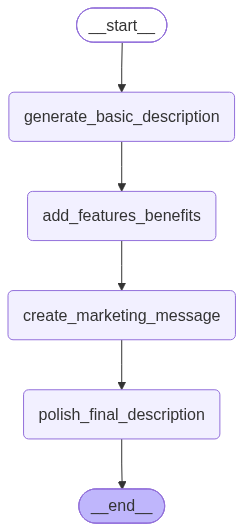

In [13]:

from IPython.display import Image, display

try:
    display(Image(chain.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [15]:
product_name = "Smart Fitness Watch"
state = State(
    product_name=product_name,
    basic_description="",
    features_benefits="",
    marketing_message="",
    final_description="",
)

result = chain.invoke(state)

In [16]:
result

{'product_name': 'Smart Fitness Watch',
 'basic_description': "A smart fitness watch is a wearable device that tracks fitness-related metrics such as heart rate, steps taken, calories burned, and distance traveled. It also has additional features like GPS, sleep tracking, and notifications for calls and messages. The watch often syncs with a smartphone app to provide a comprehensive overview of the user's activities and progress towards fitness goals. It is designed to motivate and encourage users to stay active and lead a healthy lifestyle.",
 'features_benefits': "Features and Benefits of a Smart Fitness Watch:\n\n1. **Heart Rate Monitoring**: Keep track of your heart rate during workouts to ensure you are in the optimal training zone for your fitness goals, promoting safer and more effective exercise routines.\n\n2. **Step Tracking**: Monitor your daily steps taken to motivate you to stay active and reach your daily activity targets, which can contribute to improving overall health 